In [2]:

import numpy as np
import pandas as pd 

In [3]:
import sqlite3

In [4]:
df = pd.read_csv("/Users/ishik/Desktop/brooklyn99-sql-analytics/data/All_B99_eps.csv")
df.head() 

,Season,Episode,Title,Airdate,Rating,Total Votes,Episode Description
0,1,1,Pilot,16/01/2014,7.8,4701,Detective Jake Peralta finds his work scrutini...
1,1,2,The Tagger,23/01/2014,7.5,3833,"When Jake arrives late for work, Captain Holt ..."
2,1,3,The Slump,30/01/2014,7.6,3591,"With a backlog of unsolved cases, Jake finds h..."
3,1,4,M.E. Time,06/02/2014,7.7,3473,"Jake meets an attractive Medical Examiner, but..."
4,1,5,The Vulture,13/02/2014,8.0,3370,A detective from Major Crimes takes over Jake'...


In [5]:
df.columns

Index(['Season', 'Episode', 'Title', 'Airdate', 'Rating', 'Total Votes',
       'Episode Description'],
      dtype='object')

Performing data cleaning steps

check data type of each columns

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Season               153 non-null    int64  
 1   Episode              153 non-null    int64  
 2   Title                153 non-null    object 
 3   Airdate              153 non-null    object 
 4   Rating               153 non-null    float64
 5   Total Votes          153 non-null    int64  
 6   Episode Description  153 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 8.5+ KB


In [7]:
df['Airdate'] = pd.to_datetime(df['Airdate'],dayfirst=True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Season               153 non-null    int64         
 1   Episode              153 non-null    int64         
 2   Title                153 non-null    object        
 3   Airdate              153 non-null    datetime64[ns]
 4   Rating               153 non-null    float64       
 5   Total Votes          153 non-null    int64         
 6   Episode Description  153 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(2)
memory usage: 8.5+ KB


check for nulls

In [9]:
df.isnull().sum()

Season                 0
Episode                0
Title                  0
Airdate                0
Rating                 0
Total Votes            0
Episode Description    0
dtype: int64

check for duplicates

In [10]:
df.duplicated().sum()

np.int64(0)

Composite key check: (Season, Episode) pairs should be unique together

In [11]:
is_not_unique = df.duplicated(subset=['Season', 'Episode']).any()
is_not_unique

np.False_

Outlier checks on the rating and total votes columns 

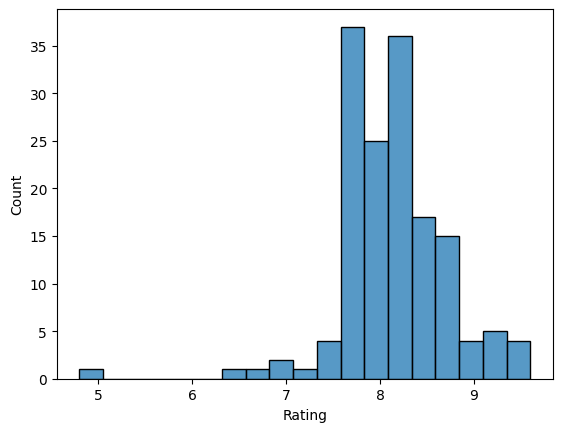

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(data=df, x="Rating")
plt.show()

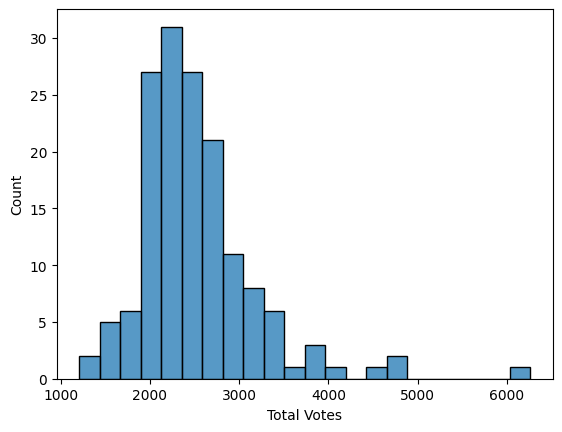

In [13]:
sns.histplot(data=df, x="Total Votes")
plt.show()

In [14]:
df.to_csv('All_B99_cleaned.csv', index=False)

In [15]:
conn = sqlite3.connect(':memory:')

In [16]:
df.to_sql('b99', conn, index=False, if_exists='replace')

153

In [17]:
query = """
SELECT *
FROM b99
LIMIT 5
"""

pd.read_sql(query, conn)

,Season,Episode,Title,Airdate,Rating,Total Votes,Episode Description
0,1,1,Pilot,2014-01-16 00:00:00,7.8,4701,Detective Jake Peralta finds his work scrutini...
1,1,2,The Tagger,2014-01-23 00:00:00,7.5,3833,"When Jake arrives late for work, Captain Holt ..."
2,1,3,The Slump,2014-01-30 00:00:00,7.6,3591,"With a backlog of unsolved cases, Jake finds h..."
3,1,4,M.E. Time,2014-02-06 00:00:00,7.7,3473,"Jake meets an attractive Medical Examiner, but..."
4,1,5,The Vulture,2014-02-13 00:00:00,8.0,3370,A detective from Major Crimes takes over Jake'...


How many total episodes exist?

In [18]:
query_1 = """
SELECT COUNT(Episode) AS total_episodes
FROM b99
"""

pd.read_sql(query_1, conn)

,total_episodes
0,153


How many seasons exists?

In [19]:
query_2 = """
SELECT COUNT(DISTINCT Season) AS number_of_season
FROM b99
"""

pd.read_sql(query_2, conn)

,number_of_season
0,8


What are the unique season numbers?

In [20]:
query_3 = """
SELECT DISTINCT Season AS distinct_seasons
FROM b99
ORDER BY Season ASC
"""

pd.read_sql(query_3, conn)

,distinct_seasons
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8


Which episode has the highest IMDb rating?

In [21]:
query_4 = """
SELECT Title 
FROM b99 
WHERE Rating IN (SELECT MAX(Rating) 
FROM b99)
"""

pd.read_sql(query_4, conn)

,Title
0,The Box
1,The Last Day Pt 2


Which episode has the lowest IMDb rating?

In [22]:
query_5 = """
SELECT Title 
FROM b99 
WHERE Rating IN (SELECT MIN(Rating)
FROM b99)
"""

pd.read_sql(query_5, conn)

,Title
0,The Good Ones


Which episodes received the most votes?

In [23]:
query_6 = """
SELECT Title 
FROM b99 
WHERE "Total Votes" IN (SELECT MAX("Total Votes")
FROM b99)
"""

pd.read_sql(query_6, conn)

,Title
0,The Box


What is the average IMDb rating of the show?

In [24]:
query_7 = """
SELECT AVG(Rating) AS average_imdb_rating
FROM b99 
"""

pd.read_sql(query_7, conn)

,average_imdb_rating
0,8.128105


Which season has the most episodes?

In [25]:
query_8 = """
WITH RankedSeasons AS (
    SELECT 
        season, 
        RANK() OVER(ORDER BY COUNT(episode) DESC) as rn
    FROM b99 
    GROUP BY season
)
SELECT season 
FROM RankedSeasons 
WHERE rn = 1
"""

pd.read_sql(query_8, conn)

,season
0,3
1,2


Find all Halloween episodes

In [26]:
query_9 = """
SELECT Season,Episode,Title 
FROM b99
WHERE "Episode Description" LIKE '%Halloween%' OR "Episode Description" LIKE '%halloween%'
"""

pd.read_sql(query_9, conn)

,Season,Episode,Title
0,1,6,Halloween
1,2,4,Halloween II
2,3,5,Halloween III
3,4,5,Halloween IV
4,5,4,HalloVeen
5,6,16,Cinco de Mayo


Find all episodes with “Doug Judy”

In [27]:
query_10 = """
SELECT Season,Episode,Title 
FROM b99
WHERE "Episode Description" LIKE '%Doug Judy%' OR "Episode Description" LIKE '%doug judy%' 
"""

pd.read_sql(query_10, conn)

,Season,Episode,Title
0,2,10,The Pontiac Bandit Returns
1,3,13,The Cruise
2,7,8,The Takeback


What is the average IMDb rating per season?

In [28]:
query_11 = """
SELECT 
      Season,AVG(Rating) AS average_rating_per_season
FROM b99
GROUP BY Season
ORDER BY average_rating_per_season DESC

"""

pd.read_sql(query_11, conn)

,Season,average_rating_per_season
0,5,8.327273
1,7,8.307692
2,4,8.177273
3,2,8.126087
4,3,8.095652
5,6,8.061111
6,1,8.040909
7,8,7.740000


Which season performed best overall?

In [29]:
query_12 = """
WITH avg_rating AS (SELECT 
      Season,
      AVG(Rating) AS average_rating_per_season, 
      RANK() OVER(ORDER BY AVG(Rating) DESC) AS rn
FROM b99
GROUP BY Season)

SELECT Season,average_rating_per_season
FROM avg_rating
WHERE rn = 1

"""

pd.read_sql(query_12, conn)

,Season,average_rating_per_season
0,5,8.327273


Which season had the most consistent ratings?

In [30]:
query_13 = """
WITH consistent_rating AS (SELECT 
      Season,
      MAX(Rating) - MIN(Rating) AS range_of_rating,
      RANK() OVER(ORDER BY MAX(Rating)-MIN(Rating)) AS rn
      
FROM b99
GROUP BY Season
ORDER BY range_of_rating ASC)

SELECT Season
FROM consistent_rating 
WHERE rn = 1


"""

pd.read_sql(query_13, conn)

,Season
0,4


Which words appear most often in episode titles?

In [31]:
df_title = df['Title'].str.replace(r'[,.]', '', regex=True).str.split(expand=True)
df_title.head()

,0,1,2,3,4
0,Pilot,None,None,None,None
1,The,Tagger,None,None,None
2,The,Slump,None,None,None
3,ME,Time,None,None,None
4,The,Vulture,None,None,None


In [32]:
df_union = df_title.stack().reset_index(drop=True).dropna()
df_words = df_union.to_frame(name = 'Words')
df_words.head()

,Words
0,Pilot
1,The
2,Tagger
3,The
4,Slump


In [33]:
df_words.to_sql('b99_title', conn, index=False, if_exists='replace')

337

In [34]:
query_14 = """
SELECT 
       Words,COUNT(Words) AS number_title_word_appearance
FROM b99_title
GROUP BY Words
ORDER BY number_title_word_appearance DESC
"""

pd.read_sql(query_14, conn)

,Words,number_title_word_appearance
0,The,47
1,House,6
2,Part,5
3,and,4
4,Pt,4
...,...,...
224,99,1
225,9-8,1
226,9,1
227,48,1


Which episode titles appear more than once?

In [35]:
query_15 = """
SELECT Title,COUNT(Title) AS number_title_name_appearance
FROM b99
GROUP BY Title
HAVING COUNT(Title) > 1


"""

pd.read_sql(query_15, conn)

,Title,number_title_name_appearance


Usually episode titles are unique so the query doesnot generate an output

Which season had the highest-rated finale?

In [36]:
query_16 = """
WITH ranking_episode AS (SELECT 
      Season,Episode,Rating,
      RANK() OVER(PARTITION BY Season ORDER BY Episode DESC) AS rn
FROM b99),

ranking_season_finale AS (
   SELECT 
      Season,Rating,RANK() OVER(ORDER BY Rating DESC) AS rank_number
   FROM ranking_episode
   WHERE rn = 1)
SELECT Season
FROM ranking_season_finale
WHERE rank_number = 1



"""

pd.read_sql(query_16, conn)

,Season
0,8


Compare early seasons vs later seasons.

In [37]:
query_17 = """ 
SELECT 
     'Early' AS Season_type,
      AVG(Rating) AS average_rating,
      COUNT(Episode) AS Total_episodes
FROM b99
WHERE Season IN (1,2,3,4)
UNION 
SELECT 
     'Later' AS Season_type,
      AVG(Rating) AS average_rating,
      COUNT(Episode) AS Total_episodes
FROM b99
WHERE Season IN (5,6,7,8)

"""

pd.read_sql(query_17, conn)

,Season_type,average_rating,Total_episodes
0,Early,8.110000,90
1,Later,8.153968,63


Which episodes are above the overall series average?

In [38]:
query_18 = """
SELECT Season,Episode,Title,Rating
FROM b99
WHERE Rating > (SELECT 
      AVG(Rating) AS average_rating_per_season
FROM b99)

"""

pd.read_sql(query_18, conn)

,Season,Episode,Title,Rating
0,1,6,Halloween,8.5
1,1,10,Thanksgiving,8.2
2,1,11,Christmas,8.2
3,1,13,The Bet,8.8
4,1,15,Operation: Broken Feather,8.2
...,...,...,...,...
66,7,11,Valloweaster,8.3
67,7,12,Ransom,8.8
68,7,13,Lights Out,9.3
69,8,9,The Last Day Pt 1,9.4


Find the top 3 highest-rated episodes per season.

In [39]:
query_19 = """
WITH episode_rating AS (SELECT
      Season,Episode,
      RANK() OVER(PARTITION BY Season ORDER BY Rating DESC) AS rank_per_season
FROM b99)

SELECT Season,Episode,rank_per_season
FROM episode_rating 
WHERE rank_per_season <= 3 


"""

pd.read_sql(query_19, conn)

,Season,Episode,rank_per_season
0,1,22,1
1,1,13,2
2,1,6,3
3,1,16,3
4,1,19,3
5,2,23,1
6,2,4,2
7,2,22,3
8,3,5,1
9,3,23,1


Which season had the biggest rating improvement over previous season?

In [40]:
query_20 = """
WITH rating_comparison AS (SELECT 
      Season,
      AVG(Rating) AS average_rating_per_season,
      LAG(AVG(Rating)) OVER (ORDER BY Season) AS previous_value,
      AVG(Rating) - LAG(AVG(Rating)) OVER (ORDER BY Season) AS difference
FROM b99
GROUP BY Season) 

SELECT Season
FROM rating_comparison
WHERE difference > 0 


"""

pd.read_sql(query_20, conn)

,Season
0,2
1,4
2,5
3,7


Rank episodes within each season

In [41]:
query_21 = """
WITH episode_ranking AS (
    SELECT
        Season,
        Episode,
        Title,
        Rating,
        RANK() OVER(
            PARTITION BY Season
            ORDER BY Rating DESC
        ) AS rank_every_season
    FROM b99
)

SELECT
    Season,
    Episode,
    Title,
    Rating,
    rank_every_season
FROM episode_ranking
ORDER BY
    Season,
    rank_every_season



"""

pd.read_sql(query_21, conn)

,Season,Episode,Title,Rating,rank_every_season
0,1,22,Charges and Specs,8.9,1
1,1,13,The Bet,8.8,2
2,1,6,Halloween,8.5,3
3,1,16,The Party,8.5,3
4,1,19,Tactical Village,8.5,3
...,...,...,...,...,...
148,8,2,The Lake House,7.9,6
149,8,4,Balancing,7.8,7
150,8,3,Blue Flu,7.0,8
151,8,6,The Set Up,6.7,9


Find the running average IMDb rating by season

In [42]:
query_22 = """
SELECT
    Season,
    Episode,
    Title,
    Rating,

    AVG(Rating) OVER(
        PARTITION BY Season
        ORDER BY Episode
        ROWS BETWEEN UNBOUNDED PRECEDING
        AND CURRENT ROW
    ) AS running_avg_rating

FROM b99
"""
pd.read_sql(query_22,conn)

,Season,Episode,Title,Rating,running_avg_rating
0,1,1,Pilot,7.8,7.800000
1,1,2,The Tagger,7.5,7.650000
2,1,3,The Slump,7.6,7.633333
3,1,4,M.E. Time,7.7,7.650000
4,1,5,The Vulture,8.0,7.720000
...,...,...,...,...,...
148,8,6,The Set Up,6.7,7.033333
149,8,7,Game of Boyles,8.1,7.185714
150,8,8,Renewal,8.1,7.300000
151,8,9,The Last Day Pt 1,9.4,7.533333


Find rating differences between consecutive episodes

In [43]:
query_23 = """
SELECT 
       Season,Episode,
       Rating - LEAD(Rating) OVER (PARTITION BY Season ORDER BY Season,Episode) AS rating_change
FROM b99



"""

pd.read_sql(query_23, conn)

,Season,Episode,rating_change
0,1,1,0.3
1,1,2,-0.1
2,1,3,-0.1
3,1,4,-0.3
4,1,5,-0.5
...,...,...,...
148,8,6,-1.4
149,8,7,0.0
150,8,8,-1.3
151,8,9,-0.2


I am assuming concecutive rating difference across all seasons and not within each season

Find consecutive highly-rated episode pairs

In [44]:
query_24 = """
WITH rating_compare AS (
    SELECT
        Season,
        Episode,
        Title,
        Rating,

        LAG(Rating) OVER(
            PARTITION BY Season
            ORDER BY Episode
        ) AS prev_rating
    FROM b99
)

SELECT *
FROM rating_compare
WHERE Rating >= 8.5
AND prev_rating >= 8.5;


"""

pd.read_sql(query_24, conn)

,Season,Episode,Title,Rating,prev_rating
0,2,23,Johnny and Dora,9.1,8.6
1,3,5,Halloween III,9.0,8.5
2,3,23,Greg and Larry,9.0,8.7
3,4,12,"The Fugitive, Part 2",8.5,8.5
4,4,22,Crime & Punishment,8.6,8.5
5,5,10,Game Night,8.6,8.8
6,6,7,The Honeypot,8.5,8.5
7,6,17,Sicko,8.5,9.2
8,6,18,Suicide Squad,9.1,8.5
9,7,13,Lights Out,9.3,8.8


Categorize episodes:
Masterpiece
Great
Average
Weak
based on IMDb rating.

In [45]:
query_25 = """
SELECT Season,Episode,Title,CASE WHEN Rating >= 8.4 THEN 'Masterpiece'
                                 WHEN Rating >= 7.2 THEN 'Great'
                                 WHEN Rating >= 6.4 THEN 'Average'
                            ELSE 'Weak' END AS episode_category
FROM b99



"""

pd.read_sql(query_25, conn)

,Season,Episode,Title,episode_category
0,1,1,Pilot,Great
1,1,2,The Tagger,Great
2,1,3,The Slump,Great
3,1,4,M.E. Time,Great
4,1,5,The Vulture,Great
...,...,...,...,...
148,8,6,The Set Up,Average
149,8,7,Game of Boyles,Great
150,8,8,Renewal,Great
151,8,9,The Last Day Pt 1,Masterpiece


For the category boundary I took the range of the values and divided it into 4 equal parts 

Find episodes rated above their season average.

In [46]:
query_26 = """
WITH season_avg AS (
    SELECT
        Season,
        AVG(Rating) AS season_avg_rating
    FROM b99
    GROUP BY Season
)

SELECT
    b.Season,
    b.Episode,
    b.Title,
    b.Rating,
    s.season_avg_rating
FROM b99 b
JOIN season_avg s
    ON b.Season = s.Season
WHERE b.Rating > s.season_avg_rating
ORDER BY b.Season, b.Rating DESC



"""

pd.read_sql(query_26, conn)

,Season,Episode,Title,Rating,season_avg_rating
0,1,22,Charges and Specs,8.9,8.040909
1,1,13,The Bet,8.8,8.040909
2,1,6,Halloween,8.5,8.040909
3,1,16,The Party,8.5,8.040909
4,1,19,Tactical Village,8.5,8.040909
...,...,...,...,...,...
73,8,7,Game of Boyles,8.1,7.740000
74,8,8,Renewal,8.1,7.740000
75,8,5,PB&J,8.0,7.740000
76,8,2,The Lake House,7.9,7.740000


Find seasons whose average rating is above series average

In [47]:
query_27 = """
WITH season_rating AS (
    SELECT
        Season,
        AVG(Rating) AS season_rating
    FROM b99
    GROUP BY Season
)

SELECT
    Season,
    ROUND(season_rating, 2) AS season_avg_rating
FROM season_rating
WHERE season_rating >
    (SELECT AVG(Rating) FROM b99)
ORDER BY season_rating DESC;
"""

pd.read_sql(query_27, conn)

,Season,season_avg_rating
0,5,8.33
1,7,8.31
2,4,8.18


Which season improved most over time?

In [48]:
query_28 = """
WITH ranked_episodes AS (
    SELECT
        Season,
        Episode,
        Rating,
        ROW_NUMBER() OVER(
            PARTITION BY Season
            ORDER BY Episode
        ) AS first_ep,
        
        ROW_NUMBER() OVER(
            PARTITION BY Season
            ORDER BY Episode DESC
        ) AS last_ep
    FROM b99
),

season_boundary AS (
    SELECT
        Season,
        MAX(CASE WHEN first_ep = 1 THEN Rating END) AS first_rating,
        MAX(CASE WHEN last_ep = 1 THEN Rating END) AS last_rating
    FROM ranked_episodes
    GROUP BY Season
),

improvement AS (
    SELECT
        Season,
        first_rating,
        last_rating,
        last_rating - first_rating AS improvement
    FROM season_boundary
)

SELECT
    Season,
    first_rating,
    last_rating,
    improvement
FROM improvement
ORDER BY improvement DESC;


"""

pd.read_sql(query_28, conn)

,Season,first_rating,last_rating,improvement
0,8,4.8,9.6,4.8
1,7,8.1,9.3,1.2
2,1,7.8,8.9,1.1
3,2,8.2,9.1,0.9
4,3,8.3,9.0,0.7
5,5,8.5,9.2,0.7
6,6,8.4,9.1,0.7
7,4,8.2,8.6,0.4


Which episodes were statistical outliers?

In [49]:
query_29 = """WITH ranked AS (
    SELECT
        Season,
        Episode,
        Title,
        Rating,
        PERCENT_RANK() OVER(
            ORDER BY Rating
        ) AS pct_rank
    FROM b99
)

SELECT *
FROM ranked
WHERE pct_rank >= 0.95
   OR pct_rank <= 0.05

"""
pd.read_sql(query_29,conn)

,Season,Episode,Title,Rating,pct_rank
0,8,1,The Good Ones,4.8,0.000000
1,6,15,Return of the King,6.4,0.006579
2,8,6,The Set Up,6.7,0.013158
3,6,8,"He Said, She Said",7.0,0.019737
4,8,3,Blue Flu,7.0,0.019737
5,7,5,Debbie,7.3,0.032895
6,6,4,Four Movements,7.4,0.039474
7,6,10,Gintars,7.4,0.039474
8,5,22,Jake & Amy,9.2,0.960526
9,6,16,Cinco de Mayo,9.2,0.960526


Which episodes caused spikes in voting activity?

In [50]:
query_30 = """
WITH votes_diff AS (SELECT Season,Episode,
       LAG("Total Votes") OVER(ORDER BY Season,Episode) - "Total Votes" AS votes_spike
FROM b99
ORDER BY votes_spike DESC) 

SELECT Season, Episode, votes_spike 
FROM votes_diff 
WHERE votes_spike > (SELECT AVG(votes_spike)
FROM votes_diff)
"""

pd.read_sql(query_30, conn)

,Season,Episode,votes_spike
0,5,15,4231
1,8,2,2624
2,5,5,2570
3,4,17,2052
4,6,9,1649
...,...,...,...
66,2,14,46
67,4,9,35
68,2,10,27
69,2,19,27


Which episodes are “cult favorites”? (high rating but lower votes)

In [51]:
query_31 = """
WITH ranked AS (SELECT Season,Episode,Title,Rating,"Total Votes",RANK() OVER(ORDER BY "Total Votes" ASC) AS popularity_rank,
       RANK() OVER(ORDER BY Rating ASC) AS appreciation_rank
FROM b99)
SELECT Season, Episode, Title, Rating, "Total Votes", popularity_rank, appreciation_rank, popularity_rank - appreciation_rank AS rank_difference
FROM ranked
"""

pd.read_sql(query_31, conn)

,Season,Episode,Title,Rating,Total Votes,popularity_rank,appreciation_rank,rank_difference
0,8,8,Renewal,8.1,1211,1,73,-72
1,8,7,Game of Boyles,8.1,1278,2,73,-71
2,8,4,Balancing,7.8,1450,3,31,-28
3,8,5,PB&J,8.0,1454,4,56,-52
4,8,6,The Set Up,6.7,1524,5,3,2
...,...,...,...,...,...,...,...,...
148,4,16,Moo Moo,8.9,4165,149,141,8
149,8,1,The Good Ones,4.8,4515,150,1,149
150,5,4,HalloVeen,9.5,4666,151,151,0
151,1,1,Pilot,7.8,4701,152,31,121


Do holiday episodes perform better?

For an episode to be considered a holiday episode, its title or description must include one of the following five holidays: New Year's, Easter, Halloween, Thanksgiving, or Christmas.

In [52]:
query_32 = """
WITH holiday_episodes AS (SELECT  Title,"Episode Description",CASE WHEN LOWER(title) = 'new year' OR LOWER("Episode Description") = 'new year' THEN 'Holiday'
                                         WHEN LOWER(title) LIKE '%easter%' OR LOWER("Episode Description") LIKE '%easter%' THEN 'Holiday'
                                         WHEN LOWER(title) LIKE '%halloween%' OR LOWER("Episode Description") LIKE '%halloween%' THEN 'Holiday'
                                         WHEN LOWER(title) LIKE '%thanksgiving%' OR LOWER("Episode Description") LIKE '%thanksgiving%' THEN 'Holiday'
                                         WHEN LOWER(title) LIKE '%christmas%' OR LOWER("Episode Description") LIKE '%christmas%' THEN 'Holiday'
                                         ELSE 'Non-Holiday' END AS episode_type, Rating
FROM b99)

SELECT episode_type,AVG(Rating) AS avg_rating_per_episode_type
FROM holiday_episodes
GROUP BY episode_type
"""

pd.read_sql(query_32, conn)

,episode_type,avg_rating_per_episode_type
0,Holiday,8.486667
1,Non-Holiday,8.089130


On an average the holiday episodes do perform better than the non-holiday ones.

Does IMDb voting correlate with rating?

In [53]:
pearson_coeff = df['Rating'].corr(df['Total Votes'], method='pearson')
print(f"Pearson Coefficient: {pearson_coeff:.4f}")

Pearson Coefficient: 0.1638


Text(0, 0.5, 'Rating')

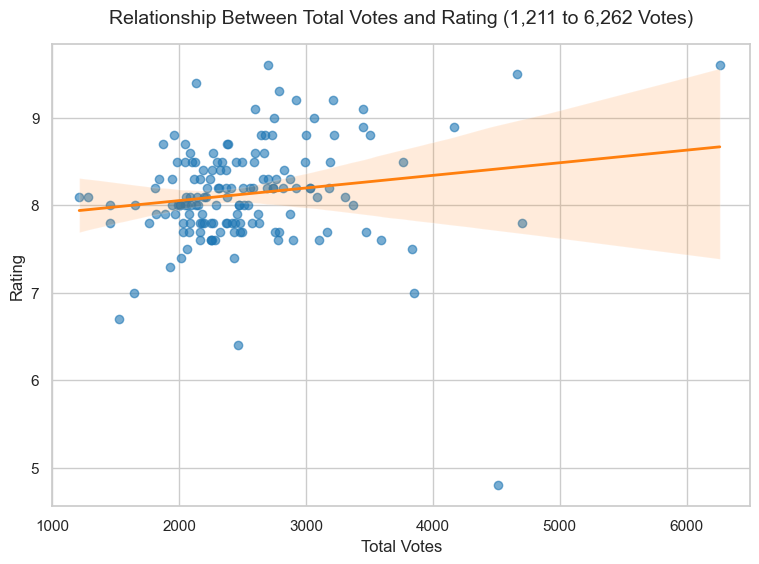

In [54]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

# Create the scatter plot with a linear trendline
sns.regplot(
    data=df, 
    x='Total Votes', 
    y='Rating', 
    scatter_kws={'alpha': 0.6, 'color': '#1f77b4'}, 
    line_kws={'color': '#ff7f0e', 'linewidth': 2}
)

# Set X-axis limits based on your actual data ranges
plt.xlim(1000, 6500)

# Title and labels
plt.title('Relationship Between Total Votes and Rating (1,211 to 6,262 Votes)', fontsize=14, pad=15)
plt.xlabel('Total Votes', fontsize=12)
plt.ylabel('Rating', fontsize=12)

The dataset consists entirely of highly established items (all exceeding 1,200 votes) with generally favorable reception, as ratings are heavily restricted to a narrow range between 7.0 and 9.0. Because of this low variance in ratings, the global correlation coefficients (Pearson: 0.16, Spearman: 0.21) remain weak, indicating that additional vote volume within this popular bracket does not meaningfully predict a higher or lower score.

Did ratings decline over time?

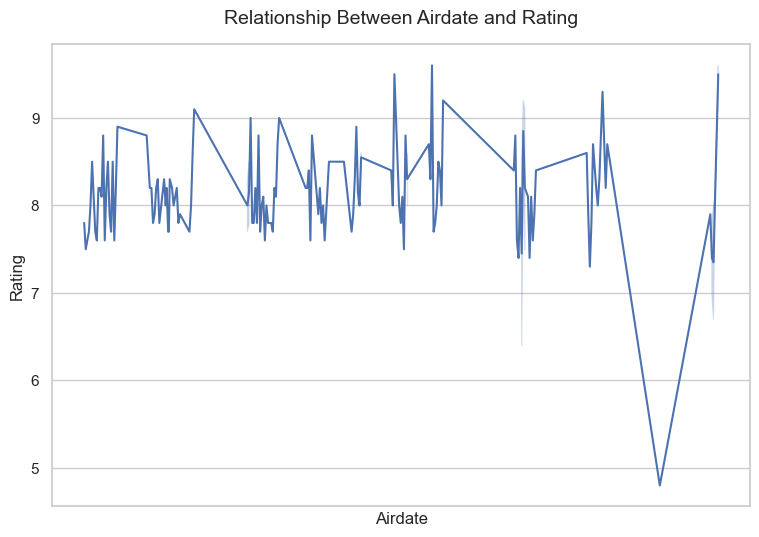

In [55]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

# Create the scatter plot with a linear trendline
sns.lineplot(data=df, x='Airdate', y='Rating')
plt.xticks([]) 


# Title and labels
plt.title('Relationship Between Airdate and Rating', fontsize=14, pad=15)
plt.xlabel('Airdate', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.show()

The show maintains a steady rating with a large dip towards the end of the sitcom(season 8).